# Batched calculation of auc roc

In [1]:
import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from matplotlib import pyplot as plt

from IPython.display import display, Markdown

## 1. Motivation and framing the challenge

A main contribution of the project is being able to train an RL agent, such that it can learn the biasing 
dynamics of an acceptance loop and be therefore able to correct them.

To do so it needs to be able to compute some metrics on a subsample of the credit data at different stages
of the biasing process. Logically the longer a financial institution has existed and has performed applicants
selection, the larger the amount of data it will have.

For an off policy RL framework this means, that a replay buffer will need to handle features of shape
`[B, N, F]`, so batch size, sub sample of observations containing only "current information" - meaning
data from up to some round which has been observed, and some amount of features. Given that the data grows
with time, the amount of valid N entries will vary across batches. This makes that a normalized tensor of
shape `[B, N, F]` will *necessarily* contain unvalid positions.

Furthermore: for the RL framework to be feasibly trained it needs to be able to calculate the metric related
to the reward in a vectorized manner. Therefore the challenge is twofold:
 
1. Find a way to calculate in a vectorized manner `B` AUC-ROCs
2. Be able to find an adequate way to mask unvalid observations

## 2. Revisiting the calculation of the AUC-ROC

Firs revist quickly and rather loosely how the ROC-Curve for binary classification is defined. The ROC-Curve
is a rank based method to assess the discriminative ability of a binary classifier. Without loss of generality
we can frame the binary classification problem as a regression problem, which tries to predict if a statistical
unit with observable features $x \in \mathcal{X}$, with $\mathcal{X}$ some feature space containing any kind
of features, is part of a class $y \in \{0, 1\}$ (note that $0, 1$ is an arbitrary encoding). Thereby the 
underlying assumption is that an observation belong either of the two classes - so there is no third option.
Then we can define a classifier $c : \mathcal{X} \to \mathcal{S} \subseteq \mathbb{R}$ as a function mapping 
some covariates $x \in \mathcal{X}$ to a scoring $s \in \mathcal{S}$, such that $c(x) = s$. The higher the scoring
the more likely it should be that a statistical unit belongs to class $1$.

Given a classifier $c$, the ROC curve is a plot of the true positive rate (TPR) on the vertical axis against 
the false positive rate (FPR) on the horizontal axis for every possible threshold setting. If the available data
was infinite the ROC-Curve would therefore be impossible to calculate, but given a finite sample, many beautiful
simplifications can be and are done. Let our sample be of size $N \in \mathbb{N}$ be indexable by the set
$\mathbf{N} = \{1, \ldots, N\} \subset \mathbb{N}$. Given this index we can define the covariates, labels and
scores as sequences $X = (x_i)_{i \in \mathbf{N}}$, $Y = (y_i)_{i \in \mathbf{N}}$ and $S = (s_i)_{i \in \mathbf{N}}$
with $s_i \equiv c(x_i)$.

Now let's define $\mathbf{O} = (o_i)_{i \in \mathbf{N}}$ as a sequence ordering the observations by descending score.
Meaning $\forall i, j \in \mathbb{N}, i < j : s_{o_i} \geq s_{o_j}$. Then every possible (meaningful) threshold lies 
in $[s_{o_N}, s_{o_1}] \subset \mathbb{R}$. Of course $s_{o_1} = \max_{i \in \mathbf{N}} s_i$
and $s_{o_N} = \min_{i \in \mathbf{N}} s_i$. Furthermore, as we do not have a scoring for every value in this interval,
we can only calculate meaningful estimates for the TPR and FPR at the points where we have observed any data. Let's see
an example with synthetic data


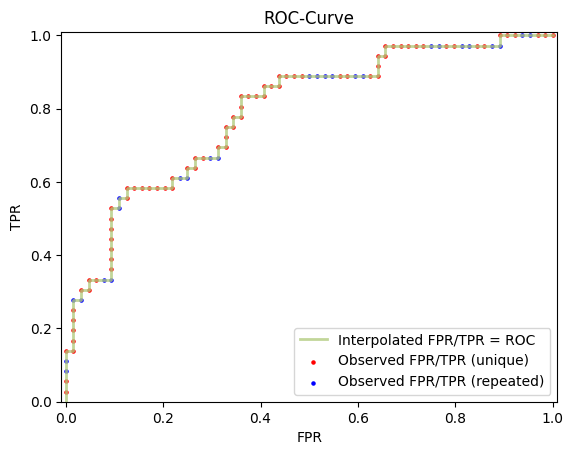

In [2]:
from batched_roc_helper import generate_data, roc_curve_with_repeats_and_interp

# Data generation
N = 100
scores, labels, idx_to_repeat = generate_data(
    N = N,
    repeated_scores = 26,
    proportion_y_equals_1=0.3
) 

scores_order = scores.argsort(descending=True)
sorted_repeated_mask = torch.any(
    torch.arange(N).unsqueeze(-1)[scores_order] == idx_to_repeat.flatten().unsqueeze(0), 
    dim=-1
)
sorted_scores = scores[scores_order]
sorted_labels = labels[scores_order]

positive_counts = int(sorted_labels.sum().item())
negative_counts = N - positive_counts

true_positives = sorted_labels.cumsum(dim=-1)
false_positives = torch.cumsum(1-sorted_labels, dim=-1)

tpr = true_positives / positive_counts
fpr = false_positives / negative_counts

roc_curve_with_repeats_and_interp(
    fpr,
    tpr,
    sorted_repeated_mask
)

The common way given this finite data to get the area under the ROC is through the trapezoidal rule.

From the code we observe that since the calculation for each threshold is basically calculating the 
FPR and TPR at the value of each observed score, can also index the FPR and the TPR by $\mathbf{O}$.
The usual way to calculate the ROC-Curve is with the trapezoidal rule. If we had no duplicated
scores the rule could be directly applied over each pair $(FPR_i, TPR_i) = (f_i, t_i)$ as
$$
AUC_{ROC} = \sum_{i=1}^N \frac{f_{o_i} - f_{o_{i-1}}}{2} (t_{o_i} + t_{o_{i-1}})
$$
with $f_{o_0} \equiv 0$ and $t_{o_0} \equiv 0$. However due to the duplicates, this would count doubly some
stretches under the curve. Therefore we need to define a new index set: $\mathbf{U} = \{u_1, \ldots , u_U\} \subseteq \mathbf{O}$,
with $U$ the amount of unique scores. This is analogous to $\mathbf{O}$ along the unique scorings, meaning
$\forall i, j \in \{1, \ldots, U\}, i < j : s_{o_i} > s_{o_j}$. The AUC-ROC is then exactly calculated as
$$
AUC_{ROC} = \sum_{i=1}^U \frac{f_{u_i} - f_{u_{i-1}}}{2} (t_{u_i} + t_{u_{i-1}})
$$

## 3. From single AUC-ROC calculation to multiple

The calculation is in general very alike, such that the problem reduces pretty much to handle cleverly two masks: one for the
valid entries and another one for the unequal scores.

We will go through the calculation with code as well, considering `B=256` batches each with a normalized length of `N=1024`.
In this case we will have a balanced setting - which should not be of any greater importance.

Also the amount of `NaN`s will be random and also the position where they will be

In [46]:
from batched_roc_helper import generate_batched_data

B, N = 256, 1024

scores, labels, _ = generate_batched_data(
    B = B,
    N = N,
    proportion_y_equals_1 = 0.5,
    repeated_scores = 64
)

rng = torch.Generator(device='cpu').manual_seed(1807)

prior_nans = torch.randint(low=10, high=round(N*0.4), size=(B,), generator=rng) / N
nan_mask = torch.bernoulli(prior_nans.unsqueeze(-1).expand(B, N), generator=rng).to(bool)
scores.masked_fill_(nan_mask, float('nan'))

print("Description of the nan counts:")
quantiles = torch.tensor([0.1,0.25,0.5,0.75,0.9])
print(
    ", ".join([f"{round(q.item(),3)}q: {round(q_v.item())}" for q, q_v in zip(quantiles, nan_mask.sum(dim=-1).to(quantiles.dtype).quantile(q=quantiles, dim=-1))])
)

Description of the nan counts:
0.1q: 60, 0.25q: 112, 0.5q: 212, 0.75q: 318, 0.9q: 377


The first step would be to redefine the sorting, making sure that unvalid positions will be at the
end of the sorting.

In [47]:
scores_order = scores.to(float).masked_fill(nan_mask, -float('inf')).argsort(dim=-1, descending=True)# [B, N]
sorted_scores = scores.gather(dim=-1, index=scores_order) # [B, N]
sorted_labels = labels.gather(dim=-1, index=scores_order) # [B, N]

Next would be counting the positives and negatives only in the valid positions.

In [48]:
mask_processed_positive_lbls = sorted_labels.masked_fill(nan_mask, 0)
mask_processed_negative_lbls = sorted_labels.masked_fill(nan_mask, 1)

positive_counts = mask_processed_positive_lbls.sum(dim=-1, keepdim=True)
negative_counts = torch.sum(1 - mask_processed_negative_lbls, dim=-1, keepdim=True)

true_positives = mask_processed_positive_lbls.cumsum(dim=-1)
false_positives = torch.cumsum(1-mask_processed_negative_lbls, dim=-1)

tpr = true_positives / positive_counts
fpr = false_positives / negative_counts

The next point is to calculate which are the positions that should be used for the trapezoidal rule.
These need to be valid *and* be unique, which can be achieved with a bitwise and between the
score change and the valid positions.

In [49]:
# N + 1 for the 0,0 to be appended for the trapz
score_change = sorted_scores.new_ones((B, N+1), dtype=bool)
if N > 1: # 0,0 is always valid and assured not to be among the sorted scores, the first one among the sorted scores must also be unique now
    score_change[:, 2:] = sorted_scores[:, 1:] != sorted_scores[:, :-1]

mask_valid_scores = ~nan_mask
mask_valid_for_trapz = (
    score_change & 
    torch.nn.functional.pad(mask_valid_scores, pad=(1,0), value=True) # Add a "column" of nan
)

zero = tpr.new_zeros(tpr.shape[:-1]).unsqueeze(-1)
tpr = torch.cat([zero, tpr], dim=-1)
fpr = torch.cat([zero, fpr], dim=-1)

## 4. A trapezoidal rule with mask support

Now the problem is reduced on defining how to handle the trapezoidal rule with masking.
The principal challenge for this is that the trapezoidal rule works with neighboring points,
which under a mask are not always equally distant from them. To handle this the idea is simple.
With help of the mask we can get a flat representations of each of the coordinates data. Since
the trapezoidal rule is more general than only the auc, now we work with x and y. 
This flat representations are almost perfect which we will see shortly

In [146]:
x = tpr
y = fpr
mask = mask_valid_for_trapz

B, N = y.shape

y_flat = y[mask]
y_flat.isnan().any().item()

False

First a little more notation. Analogous to $\mathbf{U}$ before we define this set for each batch 
$\left(y^b_i \right)_{i \in \mathbf{N}}$ as $\mathbf{U}^b = \{u^b_0, u^b_1, \ldots, u^b_{U^b}\}, b \in \{1, \ldots , B\}$. 
With this representation doing `y_flat[1:] + y_flat[:-1]` delivers a big vector looking like
$$
\texttt{y\_flat[1:] + y\_flat[:-1]} = \Big(
    \underbrace{
        \overbrace{y^1_{u^1_1} + y^1_{u^1_0}}^{\texttt{idx } 0}, \, \overbrace{y^1_{u^1_2} + y^1_{u^1_1}}^{\texttt{idx } 1}, \, 
        \ldots \, , \overbrace{y^1_{u^1_{U^1}} + y^1_{u^1_{U^1 - 1}}}^{\texttt{idx } U^1 - 1}
    }_{\text{Valid/wished sums for trapz}} , 
    \underbrace{
       \overbrace{y^2_{u^2_{0}} + y^1_{u^1_{U^1}}}^{\texttt{idx } U^1}
    }_{\text{Unvalid!}}, \,
    \underbrace{
        \overbrace{y^2_{u^2_1} + y^2_{u^2_0}}^{\texttt{idx } U^1 + 1}
    }_{\text{Valid}}, \, \ldots ,\, 
    y^B_{u^B_{U^B}} + y^B_{u^B_{U^B - 1}} 
    \Big)
$$

This shows that if we would set to 0 the summands corresponding to the summands corresponding to
the (python - so zero based) indices in the positions 
$U^1, U^1+U^2, \ldots , \sum_{b = 1}^{B-2} U^b , \sum_{b = 1}^{B-1} U^b$.
So the question is how to calculate those indices in a reliable manner. This question is also
resolved by the mask:
$$
\texttt{mask.sum(dim=-1)[b-1]} = U^b
$$
$$
\Rightarrow \texttt{mask.sum(dim=-1).cumsum(dim=-1)[b-1]} = \sum_{\beta = 1}^{b} U^\beta
$$


In [147]:
valid_count_per_batch = mask.sum(dim=-1)
cumsums_valid_counts_batch = valid_count_per_batch.cumsum(dim=-1) - 1
unvalid_summands_idx = cumsums_valid_counts_batch[:-1]

If one uses these indices of the summands to 0, they have no effect in the sum per batch - just as wished.

In [ ]:
y_flat = y[mask]
x_flat = x[mask]

y_additions = y_flat[1:] + y_flat[:-1]
# No need to set here the invalid ones to 0 because they are being multiplied by 0 anyways
x_substractions = x_flat[1:] - x_flat[:-1]

flat_summands_trapz = x_substractions * y_additions / 2
# Set unvalid to 0, effectively avoiding any mistakes when adding
flat_summands_trapz[unvalid_summands_idx] = 0

> **Note:** Even though doing first
> ```py
> y_additions[unvalid_summands_idx] = 0
> ```
> is equivalent, it is numerically less stable, that is why setting to 0 happens on the summands directly.

The next question is how to properly add the summands so that each batch gets added in the place it should.
The answer lies on calculating the batch index of each summand by simply applying the mask to a grid 
containing the batch indices. Afterwards we can use this index for scattered addition

In [ ]:
# [:-1] as the summands have exactly one less and therefore corresponds to this logic
batch_idx_summands = torch.arange(B, device=y.device).unsqueeze(-1).expand(B, N)[mask][:-1]

results_trapz = flat_summands_trapz.new_zeros((B,))
results_trapz.scatter_add_(dim=0, index=batch_idx_summands, src=flat_summands_trapz)

trapz_sequential = torch.stack([torch.trapz(y[b][mask[b]], x[b][mask[b]]) for b in range(B)])
torch.allclose(trapz_sequential, results_trapz)

True